In [1]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt

### 환경설정

In [3]:
data_path = "./data/meas_gre_dir1.mat"
slice_idx = 88
echo_idx = 0

### 1. 데이터 불러오기

In [5]:
mat_data = sio.loadmat(data_path)

print(mat_data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'B0_dir', 'CF', 'delta_TE', 'mask_brain', 'meas_gre', 'te_gre', 'tolvalue', 'voxel_size_gre'])


### 2. 데이터 정보 확인

In [7]:
for key in mat_data.keys():
    if not key.startswith("__"):
        value = mat_data[key]

        print(f"\n[{key}]")
        print("shape:", np.shape(value))
        print("dtype:", getattr(value, "dtype", type(value)))

        if np.size(value) < 20:
            print("value:", value)


[B0_dir]
shape: (1, 3)
dtype: uint8
value: [[0 0 1]]

[CF]
shape: (1, 1)
dtype: int32
value: [[123177385]]

[delta_TE]
shape: (1, 1)
dtype: float64
value: [[0.00503]]

[mask_brain]
shape: (256, 224, 176)
dtype: uint8

[meas_gre]
shape: (256, 224, 176, 6)
dtype: complex128

[te_gre]
shape: (6, 1)
dtype: float64
value: [[0.0077 ]
 [0.01273]
 [0.01776]
 [0.02279]
 [0.02782]
 [0.03285]]

[tolvalue]
shape: (1, 1)
dtype: float64
value: [[1.e-05]]

[voxel_size_gre]
shape: (3, 1)
dtype: uint8
value: [[1]
 [1]
 [1]]


### 3. 주요 데이터 추출

In [9]:
meas_gre = mat_data["meas_gre"]
mask = mat_data["mask_brain"].astype(bool)

print("meas_gre shape:", meas_gre.shape)
print("mask shape:", mask.shape)
print("meas_gre dtype:", meas_gre.dtype)
print("n_echoes:", meas_gre.shape[-1])

meas_gre shape: (256, 224, 176, 6)
mask shape: (256, 224, 176)
meas_gre dtype: complex128
n_echoes: 6


### 4. 원본 magnitude 시각화

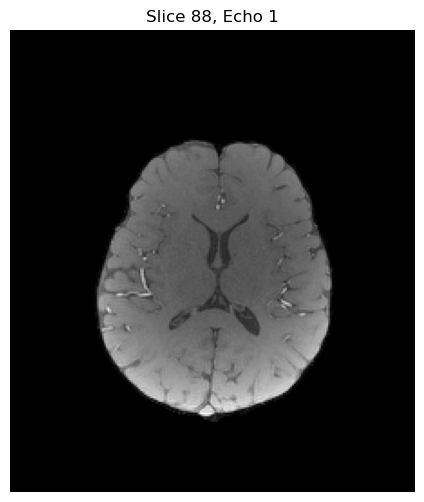

In [11]:
magnitude = np.abs(meas_gre[:, :, slice_idx, echo_idx])

plt.figure(figsize=(6, 6))
plt.imshow(magnitude, cmap="gray")
plt.title(f"Slice {slice_idx}, Echo {echo_idx + 1}")
plt.axis("off")
plt.show()

### 5. Brain mask 확인

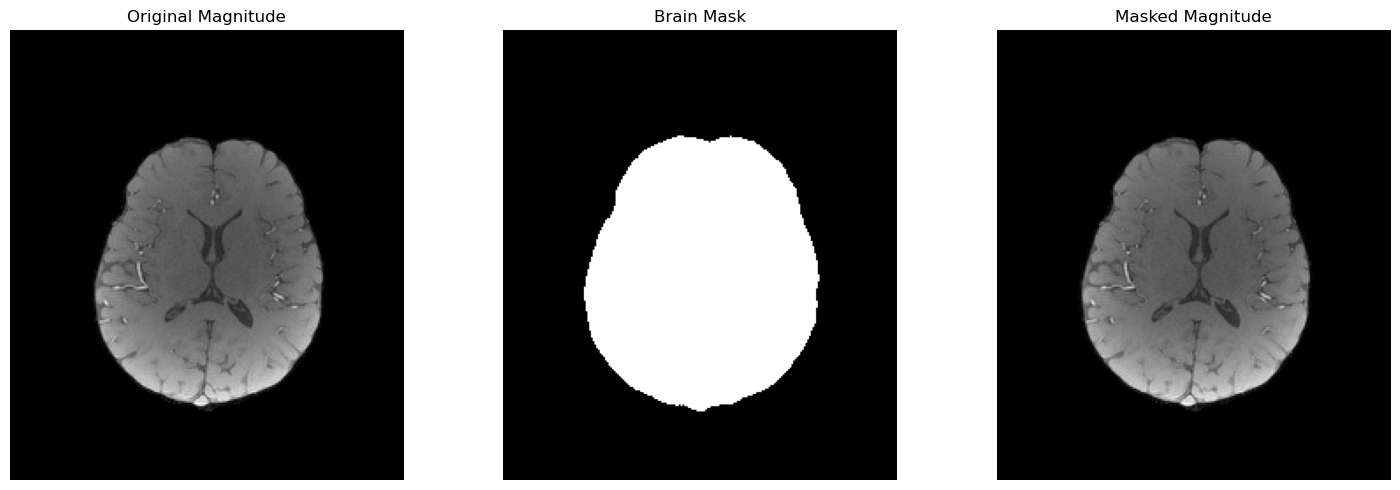

In [13]:
mask_slice = mask[:, :, slice_idx]
masked_magnitude = magnitude * mask_slice

fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].imshow(magnitude, cmap="gray")
ax[0].set_title("Original Magnitude")
ax[0].axis("off")

ax[1].imshow(mask_slice, cmap="gray")
ax[1].set_title("Brain Mask")
ax[1].axis("off")

ax[2].imshow(masked_magnitude, cmap="gray")
ax[2].set_title("Masked Magnitude")
ax[2].axis("off")

plt.tight_layout()
plt.show()

### 6. Mask 내부·외부 신호 확인

In [15]:
print("===== 전체 영역 =====")
print("원본 평균:", np.mean(magnitude))
print("mask 적용 평균:", np.mean(masked_magnitude))

print("\n===== mask 영역 내부 =====")
print("원본(mask=1) 평균:", np.mean(magnitude[mask_slice]))
print("mask 적용(mask=1) 평균:", np.mean(masked_magnitude[mask_slice]))

print("\n===== mask 영역 외부 =====")
print("원본(mask=0) 평균:", np.mean(magnitude[~mask_slice]))
print("mask 적용(mask=0) 평균:", np.mean(masked_magnitude[~mask_slice]))

background = magnitude[~mask_slice]

print("\n===== background =====")
print("background max:", np.max(background))
print("background min:", np.min(background))
print("background mean:", np.mean(background))

===== 전체 영역 =====
원본 평균: 1.1313459363068046
mask 적용 평균: 1.1313459363068046

===== mask 영역 내부 =====
원본(mask=1) 평균: 3.988190900078527
mask 적용(mask=1) 평균: 3.988190900078527

===== mask 영역 외부 =====
원본(mask=0) 평균: 0.0
mask 적용(mask=0) 평균: 0.0

===== background =====
background max: 0.0
background min: 0.0
background mean: 0.0
